In [1]:
from IPython.display import Image
import xarray as xr
import numpy as np
import math
import cartopy.crs as ccrs # for geographic plotting
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from global_land_mask import globe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.cm as cm
from matplotlib.colors import to_hex
import glob
import os
import pandas as pd
import matplotlib.colors as mcolors
import seaborn as sns

In [2]:
# Dictionnaire des modèles et de leurs chemins
cmip6_models = {
    "EC-Earth3": "/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3/piControl/r1i1p1f1/Amon/pr/gr/v20200312/",
    "EC-Earth3-Veg-LR": "/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3-Veg-LR/piControl/r1i1p1f1/Amon/pr/gr/v20200213/",
    "ACCESS-ESM1-5": "/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/piControl/r1i1p1f1/Amon/pr/gn/latest/",
    "SAMO-UNICON": "/g/data/oi10/replicas/CMIP6/CMIP/SNU/SAM0-UNICON/piControl/r1i1p1f1/Amon/pr/gn/v20190910/",
    "GFDL-ESM4": "/g/data/oi10/replicas/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/piControl/r1i1p1f1/Amon/pr/gr1/v20180701/",
    "GFDL-CM4": "/g/data/oi10/replicas/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/piControl/r1i1p1f1/Amon/pr/gr1/v20180701/",
    "NorESM2-MM": "/g/data/oi10/replicas/CMIP6/CMIP/NCC/NorESM2-MM/piControl/r1i1p1f1/Amon/pr/gn/v20191108/",
    "MRI-ESM2-0": "/g/data/oi10/replicas/CMIP6/CMIP/MRI/MRI-ESM2-0/piControl/r1i1p1f1/Amon/pr/gn/v20190222/",
    "UKESM1-0-LL": "/g/data/oi10/replicas/CMIP6/CMIP/MOHC/UKESM1-0-LL/piControl/r1i1p1f2/Amon/pr/gn/v20200828/",
    "HadGEM3-GC31-LL": "/g/data/oi10/replicas/CMIP6/CMIP/MOHC/HadGEM3-GC31-LL/piControl/r1i1p1f1/Amon/pr/gn/v20190628/",
}

dict_mslp = {    
    "EC-Earth3": "/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3/piControl/r1i1p1f1/Amon/psl/gr/v20200312/",
    "EC-Earth3-Veg-LR": "/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3-Veg-LR/piControl/r1i1p1f1/Amon/psl/gr/v20200213/",
    "ACCESS-ESM1-5": "/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/piControl/r1i1p1f1/Amon/psl/gn/latest/",
    "SAMO-UNICON": "/g/data/oi10/replicas/CMIP6/CMIP/SNU/SAM0-UNICON/piControl/r1i1p1f1/Amon/psl/gn/v20190910/",
    "GFDL-ESM4": "/g/data/oi10/replicas/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/piControl/r1i1p1f1/Amon/psl/gr1/v20180701/",
    "GFDL-CM4": "/g/data/oi10/replicas/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/piControl/r1i1p1f1/Amon/psl/gr1/v20180701/",
    "NorESM2-MM": "/g/data/oi10/replicas/CMIP6/CMIP/NCC/NorESM2-MM/piControl/r1i1p1f1/Amon/psl/gn/v20191108/",
    "MRI-ESM2-0": "/g/data/oi10/replicas/CMIP6/CMIP/MRI/MRI-ESM2-0/piControl/r1i1p1f1/Amon/psl/gn/v20190222/",
    "UKESM1-0-LL": "/g/data/oi10/replicas/CMIP6/CMIP/MOHC/UKESM1-0-LL/piControl/r1i1p1f2/Amon/psl/gn/v20200828/",
    "HadGEM3-GC31-LL": "/g/data/oi10/replicas/CMIP6/CMIP/MOHC/HadGEM3-GC31-LL/piControl/r1i1p1f1/Amon/psl/gn/v20190628/",
}

catalog = pd.read_csv('/g/data/m35/qr1706/PhD-1_CMIP_analysis/csv_npy/triple_lanina_catalog_sp.csv')

In [3]:
# Initialisation de dictionnaires distincts
pr_son, pr_djf = {}, {}
mslp_son, mslp_djf = {}, {}

for name, path_pr in cmip6_models.items():
    print(f"Extraction de {name}...")
    path_mslp = dict_mslp[name]

    try:
        ds_pr = xr.open_mfdataset(path_pr + "*.nc", chunks={'time': 120}, combine='by_coords', decode_times=False)
        ds_mslp = xr.open_mfdataset(path_mslp + "*.nc", chunks={'time': 120}, combine='by_coords', decode_times=False)
        
        # Correction IPSL
        if name == 'IPSL-CM6A-LR':
            for d in [ds_pr, ds_mslp]:
                d.time.attrs['units'] = "days since 1850-01-01 00:00:00"
                d.time.attrs['calendar'] = 'proleptic_gregorian'

        ds_p = xr.decode_cf(ds_pr, use_cftime=True)
        ds_m = xr.decode_cf(ds_mslp, use_cftime=True)

        pr = ds_p.pr * 86400
        msl = ds_m.psl / 100.0 

        model_cal = ds_p.time.encoding.get('calendar', ds_p.time.attrs.get('calendar', 'standard'))

        # Climatologies globales
        clim_pr_all = pr.groupby("time.month").mean(dim="time").compute()
        clim_msl_all = msl.groupby("time.month").mean(dim="time").compute()
        
        # Préparation des sous-dictionnaires
        pr_son[name], pr_djf[name] = {}, {}
        mslp_son[name], mslp_djf[name] = {}, {}

        for i, y_lab in enumerate(["yr1", "yr2", "yr3"]):
            ev_pr_son, ev_msl_son = [], []
            ev_pr_djf, ev_msl_djf = [], []
            
            triple_starts = catalog[catalog['model'] == name]['triple_start_year'].values
            
            for start_year in triple_starts:
                target_year = int(start_year) + i
                try:
                    # Dates SON
                    d1_son = xr.cftime_range(start=f"{target_year:04d}-09-01", periods=1, calendar=model_cal)[0]
                    d2_son = xr.cftime_range(start=f"{target_year:04d}-11-30", periods=1, calendar=model_cal)[0]
                    
                    # Dates DJF
                    d1_djf = xr.cftime_range(start=f"{target_year:04d}-12-01", periods=1, calendar=model_cal)[0]
                    d2_djf = xr.cftime_range(start=f"{(target_year+1):04d}-02-28", periods=1, calendar=model_cal)[0]

                    # Extraction SON
                    s_pr_son = pr.sel(time=slice(d1_son, d2_son)).mean(dim='time').compute()
                    s_msl_son = msl.sel(time=slice(d1_son, d2_son)).mean(dim='time').compute()
                    if s_pr_son.notnull().any():
                        ev_pr_son.append(s_pr_son)
                        ev_msl_son.append(s_msl_son)
                        
                    # Extraction DJF
                    s_pr_djf = pr.sel(time=slice(d1_djf, d2_djf)).mean(dim='time').compute()
                    s_msl_djf = msl.sel(time=slice(d1_djf, d2_djf)).mean(dim='time').compute()
                    if s_pr_djf.notnull().any():
                        ev_pr_djf.append(s_pr_djf)
                        ev_msl_djf.append(s_msl_djf)
                except: continue

            # Stockage SON
            if ev_pr_son:
                pr_son[name][y_lab] = {
                    'stacked_events': xr.concat(ev_pr_son, dim='event'), 
                    'clim_ref': clim_pr_all.sel(month=[9, 10, 11]).mean(dim='month'),
                    'n': len(ev_pr_son)
                }
                mslp_son[name][y_lab] = {
                    'stacked': xr.concat(ev_msl_son, dim='event'), 
                    'clim': clim_msl_all.sel(month=[9, 10, 11]).mean(dim='month')
                }
                
            # Stockage DJF
            if ev_pr_djf:
                pr_djf[name][y_lab] = {
                    'stacked_events': xr.concat(ev_pr_djf, dim='event'), 
                    'clim_ref': clim_pr_all.sel(month=[12, 1, 2]).mean(dim='month'),
                    'n': len(ev_pr_djf)
                }
                mslp_djf[name][y_lab] = {
                    'stacked': xr.concat(ev_msl_djf, dim='event'), 
                    'clim': clim_msl_all.sel(month=[12, 1, 2]).mean(dim='month')
                }

        ds_pr.close(); ds_mslp.close()

    except Exception as e:
        print(f"Erreur avec {name}: {e}")

Extraction de EC-Earth3...
Extraction de EC-Earth3-Veg-LR...
Extraction de ACCESS-ESM1-5...
Extraction de SAMO-UNICON...
Extraction de GFDL-ESM4...
Extraction de GFDL-CM4...
Extraction de NorESM2-MM...
Extraction de MRI-ESM2-0...
Extraction de UKESM1-0-LL...
Extraction de HadGEM3-GC31-LL...


In [4]:
def process_agreement(input_dict, threshold=0.80):
    output_dict = {}
    target_lat = np.arange(-55, 12, 2)
    target_lon = np.arange(80, 182, 2)
    
    for name in input_dict.keys():
        output_dict[name] = {}
        for y_lab in ["yr1", "yr2", "yr3"]:
            try:
                data = input_dict[name][y_lab]
                
                # Anomalie %
                anom_pc = (data['stacked_events'].mean(dim='event') / data['clim_ref'] - 1) * 100
                
                # Masque
                anom_indiv = data['stacked_events'] - data['clim_ref']
                n = data['n']
                needed = np.ceil(n * threshold)
                
                agreement = (anom_indiv > 0).sum(dim='event') >= needed
                disagreement = (anom_indiv < 0).sum(dim='event') >= needed
                mask_native = (agreement | disagreement) & (np.abs(anom_pc) > 10)
                
                # Regridding du masque
                curr_lat = [c for c in mask_native.coords if 'lat' in c.lower()][0]
                curr_lon = [c for c in mask_native.coords if 'lon' in c.lower()][0]
                mask_interp = mask_native.astype(float).interp(
                    {curr_lat: target_lat, curr_lon: target_lon}, 
                    method='nearest'
                )
                
                output_dict[name][y_lab] = {'anom': anom_pc, 'mask_pts': mask_interp, 'n': n}
            except: continue
    return output_dict

def get_ensemble_mean_with_mslp(processed_dict_pr, raw_dict_mslp):
    target_lat = np.arange(-55, 11, 1)
    target_lon = np.arange(80, 181, 1)
    ensemble_results = {}
    
    for y_lab in ["yr1", "yr2", "yr3"]:
        anoms_pr, anoms_mslp = [], []
        common_models = set(processed_dict_pr.keys()) & set(raw_dict_mslp.keys())
        
        for m_name in common_models:
            if y_lab in processed_dict_pr[m_name] and y_lab in raw_dict_mslp[m_name]:
                # Pluie
                d_pr = processed_dict_pr[m_name][y_lab]
                anoms_pr.append(d_pr['anom'].interp(lat=target_lat, lon=target_lon, method='linear'))
                
                # Pression
                d_mslp = raw_dict_mslp[m_name][y_lab]
                msl_anom_raw = d_mslp['stacked'].mean(dim='event') - d_mslp['clim']
                anoms_mslp.append(msl_anom_raw.interp(lat=target_lat, lon=target_lon, method='linear'))
        
        if anoms_pr:
            # Concaténation pour calculs inter-modèles
            anoms_da = xr.concat(anoms_pr, dim='model')
            ens_pr = anoms_da.mean(dim='model', skipna=True).compute()
            ens_mslp = xr.concat(anoms_mslp, dim='model').mean(dim='model', skipna=True).compute()
            
            # --- CALCUL DU MASQUE D'ACCORD (85%) ---
            n_models = len(anoms_pr)
            needed_models = np.ceil(0.85 * n_models)
            
            pos_agree = (anoms_da > 0).sum(dim='model') >= needed_models
            neg_agree = (anoms_da < 0).sum(dim='model') >= needed_models
            ens_mask = pos_agree | neg_agree
            
            # Application du seuil de 10% d'anomalie, comme dans votre autre code
            ens_mask = ens_mask & (np.abs(ens_pr) > 10)
            
            # On prend un point tous les 3 points de grille afin d'avoir un graphique plus joli
            ens_mask = ens_mask.isel(lat=slice(0, None, 2), lon=slice(0, None, 2))
            
            ensemble_results[y_lab] = {'anom': ens_pr, 'mslp': ens_mslp, 'mask_pts': ens_mask, 'n': n_models}
            
    return ensemble_results

In [5]:
# 1. On applique le masque d'accord sur les pluies
processed_pr_son = process_agreement(pr_son, threshold=0.80)
processed_pr_djf = process_agreement(pr_djf, threshold=0.80)

# 2. On calcule la moyenne d'ensemble (pluie et pression en même temps)
ens_son = get_ensemble_mean_with_mslp(processed_pr_son, mslp_son)
ens_djf = get_ensemble_mean_with_mslp(processed_pr_djf, mslp_djf)

# Un petit test pour se rassurer que les données sont bien différentes maintenant
diff_test = ens_son['yr1']['anom'].mean().values - ens_djf['yr1']['anom'].mean().values
print(f"Différence SON vs DJF : {diff_test} (doit être différent de 0.0)")

Différence SON vs DJF : 0.5016385738952174 (doit être différent de 0.0)


/home/561/qr1706/.local/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:1604: UserWarning: No contour levels were found within the data range.
  result = super().contour(*args, **kwargs)
/jobfs/163277694.gadi-pbs/ipykernel_1715612/661390546.py:82: MatplotlibDeprecationWarning: The 'extend' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', extend='both')


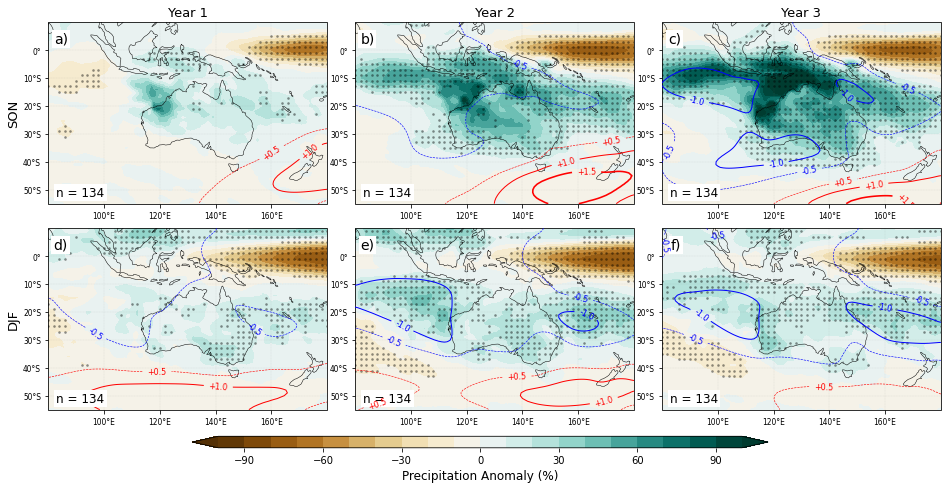

In [7]:
from scipy.ndimage import gaussian_filter
import cartopy.mpl.ticker as cticker

def add_mslp_contours(ax, mslp_anom, lon_range=(80, 180), lat_range=(-55, 10)):
    mslp_reg = mslp_anom.sel(
        lon=slice(min(lon_range), max(lon_range)),
        lat=slice(min(lat_range), max(lat_range))
    )
    
    data_filled = mslp_reg.fillna(0).values
    smoothed_data = gaussian_filter(data_filled, sigma=1.2)
    lons = mslp_reg.lon.values
    lats = mslp_reg.lat.values

    pos_levs = [0.5, 1.0, 1.5, 2.0]
    neg_levs = [-2.0, -1.5, -1.0, -0.5]

    cs_pos = ax.contour(lons, lats, smoothed_data, levels=pos_levs,
                        colors='red', linewidths=[0.6, 1.0, 1.6, 2.2],
                        linestyles=['--', '-', '-', '-'],
                        transform=ccrs.PlateCarree(), zorder=10)
    ax.clabel(cs_pos, fmt='%+.1f', fontsize=8, inline=True)

    cs_neg = ax.contour(lons, lats, smoothed_data, levels=neg_levs,
                        colors='blue', linewidths=[2.2, 1.6, 1.0, 0.6],
                        linestyles=['-', '-', '-', '--'],
                        transform=ccrs.PlateCarree(), zorder=10)
    ax.clabel(cs_neg, fmt='%+.1f', fontsize=8, inline=True)

# --- CODE DU PLOT ---
fig, axes = plt.subplots(2, 3, figsize=(16, 8), subplot_kw={'projection': ccrs.PlateCarree()})
fig.subplots_adjust(wspace=0.1, hspace=-0.1)

labels = ['a)','b)','c)','d)','e)','f)']
label_idx = 0

for r, (seas_name, current_ens) in enumerate([('SON', ens_son), ('DJF', ens_djf)]):
    for c, y_lab in enumerate(["yr1", "yr2", "yr3"]):
        ax = axes[r, c]
        
        pr_to_plot = current_ens[y_lab]['anom'].fillna(0)
        mslp_to_plot = current_ens[y_lab]['mslp'].fillna(0)

        im = ax.contourf(pr_to_plot.lon, pr_to_plot.lat, pr_to_plot.values,
                         levels=np.arange(-100, 110, 10), cmap='BrBG', 
                         extend='both', transform=ccrs.PlateCarree())

        add_mslp_contours(ax, mslp_to_plot)

        # --- AJOUT DU STIPPLING ---
        m_pts = current_ens[y_lab]['mask_pts']
        lat_idx, lon_idx = np.where(m_pts.values == True)
        
        if len(lat_idx) > 0:
            ax.scatter(m_pts.lon.values[lon_idx], m_pts.lat.values[lat_idx], 
                       marker='o', s=3, color='black', 
                       alpha=0.3, transform=ccrs.PlateCarree(), zorder=5)

        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.set_extent([80, 180, -55, 10], crs=ccrs.PlateCarree())

        ax.text(0.03, 0.04, f"n = 134", transform=ax.transAxes, fontsize=12,
                bbox=dict(facecolor='white', alpha=1, edgecolor='none', pad=2), zorder=10)
        
        ax.text(0.07, 0.87, labels[label_idx], transform=ax.transAxes, fontsize=14, 
                va='bottom', ha='right', bbox=dict(facecolor='white', alpha=1, edgecolor='none', pad=2), zorder=10)
        label_idx += 1

        if r == 0: ax.set_title(f"Year {c+1}", fontsize=13)
        if c == 0:
            ax.text(-0.1, 0.5, seas_name, transform=ax.transAxes, 
                    fontsize=13, rotation=90, va='center', ha='right')

        ax.set_xticks([100, 120, 140, 160], crs=ccrs.PlateCarree())
        ax.set_yticks([-50, -40, -30, -20, -10, 0], crs=ccrs.PlateCarree())
        ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
        ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
        ax.tick_params(labelsize=7.5)
        ax.grid(linewidth=0.3, linestyle='--', color='gray', alpha=0.3)

cbar_ax = fig.add_axes([0.25, 0.1, 0.5, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', extend='both')
cbar.set_label('Precipitation Anomaly (%)', fontsize=12)

fig.savefig('/g/data/m35/qr1706/PhD-1_CMIP_analysis/png/pr/Pr_CMIP6_TLN_85pct_MSLP.png',
            bbox_inches='tight', dpi=600)

plt.show()